# Loading Libraries and Packages

In [36]:
import copy, math, os, time
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import StandardScaler

# Setting the random seed for reproducibility
np.random.seed(42)

import warnings
warnings.filterwarnings("ignore")

if torch.backends.mps.is_available():
    print(f"MPS available. \nUsing MPS as runtime.")
    device = torch.device("mps")
    
elif torch.cuda.is_available():
    print(f"CUDA available. \nUsing CUDA as runtime.")
    device = torch.device("cuda")

else:
    print(f"No GPU available. \nUsing CPU runtime.")
    device = torch.device('cpu')

MPS available. 
Using MPS as runtime.


# 4.10 LSTM Gradient Rescue

## Loading and Flattening the Dataset

In [3]:
def flatten_data(X, y, window=72, time_ahead=24):

    X_flat, y_flat = [], []
    curr_index = window

    while (curr_index + time_ahead) < X.shape[0]:
        X_flat.append(X[curr_index-window:curr_index])
        y_flat.append(y[curr_index + time_ahead])  # no flatten()
        curr_index += 1

    return np.array(X_flat), np.array(y_flat)

In [4]:
def get_phase4_data(input_columns, target_columns, time_steps = 24, sliding_window = 72, preprocess = True):
    # Creating Dataframe
    data_path = "../delhi_aqi.csv" 
    df = pd.read_csv(data_path)
    
    # Input Data
    X = np.array(df[input_columns].copy())
    y = np.array(df[[target_columns]].copy())
    
    # Train-Validation-Split Split (70-15-15)
    train_pct = 0.7
    val_pct = 0.15
    test_pct = 0.15
    
    
    train_index = int(X.shape[0]*train_pct)
    val_index = train_index + int(math.ceil(X.shape[0]*val_pct))
    
    X_train = X[:train_index].copy() # Training Data
    X_val = X[train_index:val_index].copy() # Validation Data
    X_test = X[val_index:].copy() # Test Data

    y_train = y[:train_index].copy() # Training Data
    y_val = y[train_index:val_index].copy() # Validation Data
    y_test = y[val_index:].copy() # Test Data

    std_scaler = StandardScaler()
    std_scaler_target = StandardScaler()

    # Pre-processing Data
    if preprocess:
        print("Standard Scaler applied on Data.")
        # --- Correct scaling ---
        X_train = std_scaler.fit_transform(X_train)
        X_val   = std_scaler.transform(X_val)
        X_test  = std_scaler.transform(X_test)
        
        y_train = std_scaler_target.fit_transform(y_train) 
        y_val   = std_scaler_target.transform(y_val)
        y_test  = std_scaler_target.transform(y_test)

    print()
    print("Input Data Shape:", X.shape)
    print("Input Target Shape:", y.shape)
    
    print()
    print("#"*10, "Dimensions of Original Dataset","#"*10)
    print()
    
    print(f"Train Data Shape: {X_train.shape}")
    print(f"Train Target Shape: {y_train.shape}")
    
    print(f"Validation Data Shape: {X_val.shape}")
    print(f"Validation Target Shape: {y_val.shape}")
    
    print(f"Test Data Shape: {X_test.shape}")
    print(f"Test Target Shape: {y_test.shape}")
    
    print()
    print("#"*10, "Dimensions After Flattening","#"*10)
    print()
    X_train, y_train = flatten_data(X_train,y_train, time_ahead = time_steps, window = sliding_window)
    X_val, y_val = flatten_data(X_val,y_val, time_ahead = time_steps, window = sliding_window)
    X_test, y_test = flatten_data(X_test, y_test, time_ahead = time_steps, window = sliding_window)
    
    print(f"Train Data Shape: {X_train.shape}")
    print(f"Train Target Shape: {y_train.shape}")
    
    print(f"Validation Data Shape: {X_val.shape}")
    print(f"Validation Target Shape: {y_val.shape}")
    
    print(f"Test Data Shape: {X_test.shape}")
    print(f"Test Target Shape: {y_test.shape}")
    
    
    
    return {
        'train': (X_train, y_train),
        'val': (X_val, y_val),
        'test': (X_test, y_test),
        'std_scalers': (std_scaler, std_scaler_target)
    }

## LSTM Class

In [5]:
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()

        self.input_dim = input_size
        self.hidden_dim = hidden_size
        self.output_dim = output_size

        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)

        self.output_layer = nn.Linear(hidden_size, output_size)

    def forward(self, X):
        # X: (batch, seq_len, input_dim)
        out, (h_n, c_n) = self.lstm(X)
        # Take final hidden state
        h_final = h_n[-1]
        out = self.output_layer(h_final)

        return out

## LSTM BPTT Experiment

In [6]:
def run_lstm_bptt_experiment(model, X, y):
    """
    X: (batch_size, seq_len, input_dim)
    y: (batch_size, output_dim)
    """

    model.eval()
    device = torch.device("cpu")

    model = model.to(device)

    # --- Use ONLY ONE sample ---
    X = X[0:1].to(device)   # (1, 100, 8)
    y = y[0:1].to(device)

    seq_len = X.shape[1]

    # Initialize states
    h = torch.zeros(1, 1, model.hidden_dim, device=device)
    c = torch.zeros(1, 1, model.hidden_dim, device=device)

    grad_norms = [0.0] * seq_len

    # --- Forward pass ---
    for t in range(seq_len):
        x_t = X[:, t:t+1, :]  # (1, 1, input_dim)

        out, (h, c) = model.lstm(x_t, (h, c))

        # Hook per timestep
        def save_grad(timestep):
            def hook(grad):
                grad_norms[timestep] = grad.norm().item()
            return hook

        h.register_hook(save_grad(t))

    # Final output
    out = model.output_layer(h.squeeze(0))

    # Use REAL target instead of random
    loss = nn.MSELoss()(out, y)

    model.zero_grad(set_to_none=True)
    loss.backward()

    return grad_norms

## Load Data and Run experiment

In [7]:
input_columns = ['co', 'no', 'no2', 'o3', 'so2', 'pm2_5', 'pm10', 'nh3']
target_columns = 'pm2_5'

# Getting and Flattening Data
phase4_data = get_phase4_data(input_columns, target_columns, sliding_window = 100, time_steps = 24)
std_scaler_data, std_scaler_target = phase4_data['std_scalers'] # Needed to re-construct the original values

X_train, y_train = phase4_data['train']
X_val, y_val = phase4_data['val']
X_test, y_test = phase4_data['test']

X_train = torch.tensor(X_train, dtype = torch.float32).to(device)
X_val = torch.tensor(X_val, dtype = torch.float32).to(device)
X_test = torch.tensor(X_test, dtype = torch.float32).to(device)

y_train = torch.tensor(y_train, dtype = torch.float32).to(device)
y_val =  torch.tensor(y_val, dtype = torch.float32).to(device)
y_test = torch.tensor(y_test, dtype = torch.float32).to(device)

Standard Scaler applied on Data.

Input Data Shape: (18776, 8)
Input Target Shape: (18776, 1)

########## Dimensions of Original Dataset ##########

Train Data Shape: (13143, 8)
Train Target Shape: (13143, 1)
Validation Data Shape: (2817, 8)
Validation Target Shape: (2817, 1)
Test Data Shape: (2816, 8)
Test Target Shape: (2816, 1)

########## Dimensions After Flattening ##########

Train Data Shape: (13019, 100, 8)
Train Target Shape: (13019, 1)
Validation Data Shape: (2693, 100, 8)
Validation Target Shape: (2693, 1)
Test Data Shape: (2692, 100, 8)
Test Target Shape: (2692, 1)


In [8]:
print(f"Running Model on {device}.\n")

# LSTM model
lstm_model = LSTMModel(input_size=8, hidden_size=32, output_size=1).to(device)

# Run experiment
grad_norms_lstm = run_lstm_bptt_experiment(lstm_model, X_train,y_train)

print("LSTM Gradient norms:")
print(f"t = 100: {grad_norms_lstm[99]}")
print(f"t = 50 : {grad_norms_lstm[49]}")
print(f"t = 1  : {grad_norms_lstm[0]}")

Running Model on mps.

LSTM Gradient norms:
t = 100: 1.0876410007476807
t = 50 : 2.123272217768868e-11
t = 1  : 4.908128267268458e-21


## Visualization of Gradient Norms

In [1]:
def plot_gradient_decay(grad_norms, save_path=None, values_path=None):
    timesteps = list(range(1, len(grad_norms) + 1))

    # --- Save gradient values ---
    if values_path is not None:
        np.save(values_path, np.array(grad_norms))   # saves as .npy file

    plt.figure(figsize=(10, 6))

    plt.plot(
        timesteps,
        grad_norms,
        linewidth=2
    )

    plt.xlabel("Time Step", fontsize=12)
    plt.ylabel("Gradient Norm ||dL/dh_t||", fontsize=12)
    plt.title("Vanishing Gradient in Vanilla RNN (BPTT)", fontsize=14)

    # --- LOG SCALE ---
    plt.yscale('log')

    # Grid
    plt.grid(True, linestyle='--', linewidth=0.6, alpha=0.7)

    # Highlight key points
    # key_steps = [1, 50, 100]
    key_steps = [ 50, 100]
    # key_vals = [grad_norms[0], grad_norms[49], grad_norms[99]]
    key_vals = [grad_norms[49], grad_norms[99]]


    plt.scatter(key_steps, key_vals, zorder=3)

    # Annotate
    for t, val in zip(key_steps, key_vals):
        plt.text(t, val, f"{val:.2e}", fontsize=9, va='bottom')

    plt.tight_layout()

    # --- Save plot ---
    if save_path:
        plt.savefig(save_path, dpi=300)   # FIXED typo

    plt.show()

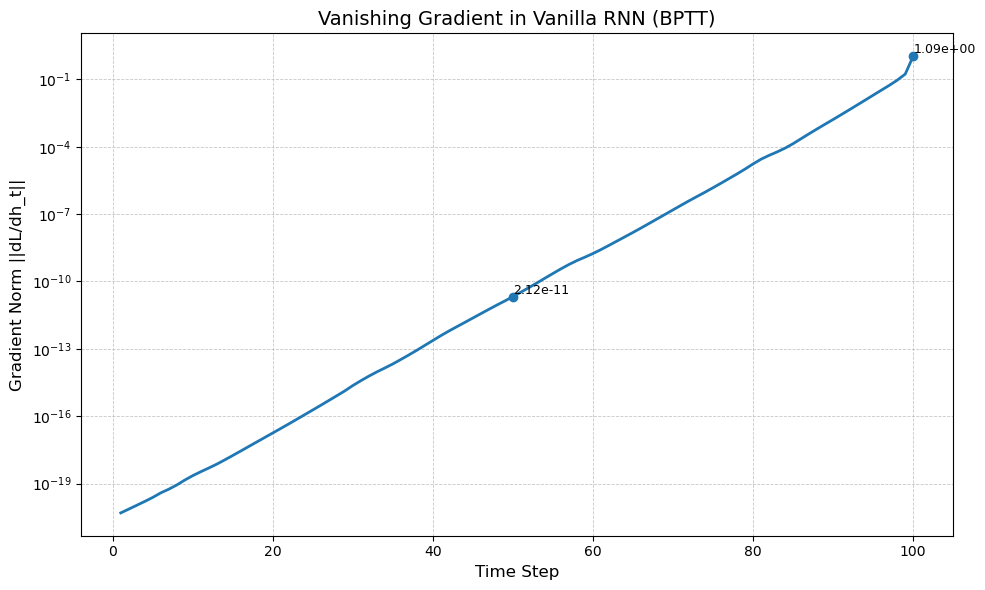

In [11]:
plot_gradient_decay(
    grad_norms_lstm,
    save_path="../Report/4_10_bptt_decay_lstm.png",
    values_path="../Report/gradients_lstm.npy"
)

In [18]:
import numpy as np
import matplotlib.pyplot as plt

def plot_rnn_vs_lstm(rnn_path, lstm_path, save_path=None, eps=1e-20):

    rnn = np.load(rnn_path)
    lstm = np.load(lstm_path)

    rnn_safe = np.maximum(rnn, eps)
    lstm_safe = np.maximum(lstm, eps)

    timesteps = np.arange(1, len(rnn_safe) + 1)

    plt.figure(figsize=(10, 6))

    plt.plot(timesteps, rnn_safe, linewidth=2.5, linestyle='--', label="Vanilla RNN")
    plt.plot(timesteps, lstm_safe, linewidth=2.5, linestyle='-', label="LSTM")

    plt.yscale('log')

    plt.xlabel("Time Step", fontsize=12)
    plt.ylabel(r"Gradient Norm $\|\partial L / \partial h_t\|$", fontsize=12)
    plt.title("Gradient Flow Comparison: Vanilla RNN vs LSTM", fontsize=14)

    plt.grid(True, linestyle='--', linewidth=0.6, alpha=0.7)

    key_idx = [0, 49, 99]

    for i in key_idx:
        x = i + 1

        # --- RNN point (place BELOW) ---
        plt.scatter(x, rnn_safe[i], s=45, zorder=3)
        plt.annotate(
            f"{rnn[i]:.2e}",
            (x, rnn_safe[i]),
            textcoords="offset points",
            xytext=(0, -15),   # BELOW
            ha='center',
            fontsize=9
        )

        # --- LSTM point (place ABOVE + slight horizontal shift) ---
        shift = 5 if x == 100 else 0  # avoid right-edge collision

        plt.scatter(x, lstm_safe[i], s=45, zorder=3)
        plt.annotate(
            f"{lstm[i]:.2e}",
            (x, lstm_safe[i]),
            textcoords="offset points",
            xytext=(shift, 10),   # ABOVE
            ha='center',
            fontsize=9
        )

    plt.legend(fontsize=11)

    ymin = min(rnn_safe.min(), lstm_safe.min())
    ymax = max(rnn_safe.max(), lstm_safe.max())
    plt.ylim(ymin, ymax * 1.5)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300)

    plt.show()

In [34]:
import numpy as np
import matplotlib.pyplot as plt

def plot_rnn_vs_lstm_improved(rnn_path, lstm_path, save_path=None, eps=1e-20):

    rnn = np.load(rnn_path)
    lstm = np.load(lstm_path)

    rnn_safe = np.maximum(rnn, eps)
    lstm_safe = np.maximum(lstm, eps)

    timesteps = np.arange(1, len(rnn_safe) + 1)

    plt.figure(figsize=(10, 6))

    # --- Plot lines ---
    plt.plot(timesteps, rnn_safe, linewidth=2.5, linestyle='--', label="Vanilla RNN")
    plt.plot(timesteps, lstm_safe, linewidth=2.5, linestyle='-', label="LSTM")

    plt.yscale('log')

    plt.xlabel("Time Step", fontsize=12)
    plt.ylabel(r"Gradient Norm $\|\partial L / \partial h_t\|$", fontsize=12)
    plt.title("Gradient Flow Comparison: Vanilla RNN vs LSTM", fontsize=14)

    plt.grid(True, linestyle='--', linewidth=0.6, alpha=0.7)

    # --- Key points (1, 50, 100) ---
    key_idx = [0, 49, 99]

    for i in key_idx:
        x = i + 1

        # RNN (below)
        plt.scatter(x, rnn_safe[i], s=45, zorder=3, c='blue')
        plt.annotate(f"{rnn[i]:.2e}",
                     (x, rnn_safe[i]),
                     textcoords="offset points",
                     xytext=(0, -15),
                     ha='center',
                     fontsize=9)

        # LSTM (above)
        shift = 5 if x == 100 else 0
        plt.scatter(x, lstm_safe[i], s=45, zorder=3, c='brown')
        plt.annotate(f"{lstm[i]:.2e}",
                     (x, lstm_safe[i]),
                     textcoords="offset points",
                     xytext=(shift, 10),
                     ha='center',
                     fontsize=9)

    # --- Detect first zero (vanishing point) ---
    threshold = 1e-22
    nonzero_indices = np.where(rnn > threshold)[0]
    
    if len(nonzero_indices) > 0:
        vanish_idx = max(nonzero_indices[0] - 1, 0)
        vanish_t = vanish_idx + 1
    
        # Marker
        plt.scatter(vanish_t, eps, s=80, marker='x', zorder=4)
    
        # Vertical line
        plt.axvline(vanish_t, linestyle=':', linewidth=1.5)
    
        # Annotation
        plt.annotate(
            f"Vanishing region (t ≤ {vanish_t})",
            (vanish_t, eps),
            textcoords="offset points",
            xytext=(10, 10),
            fontsize=9)
        plt.legend(fontsize=11)

    ymin = min(rnn_safe.min(), lstm_safe.min())
    ymax = max(rnn_safe.max(), lstm_safe.max())
    plt.ylim(ymin, ymax * 1.5)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300)

    plt.show()

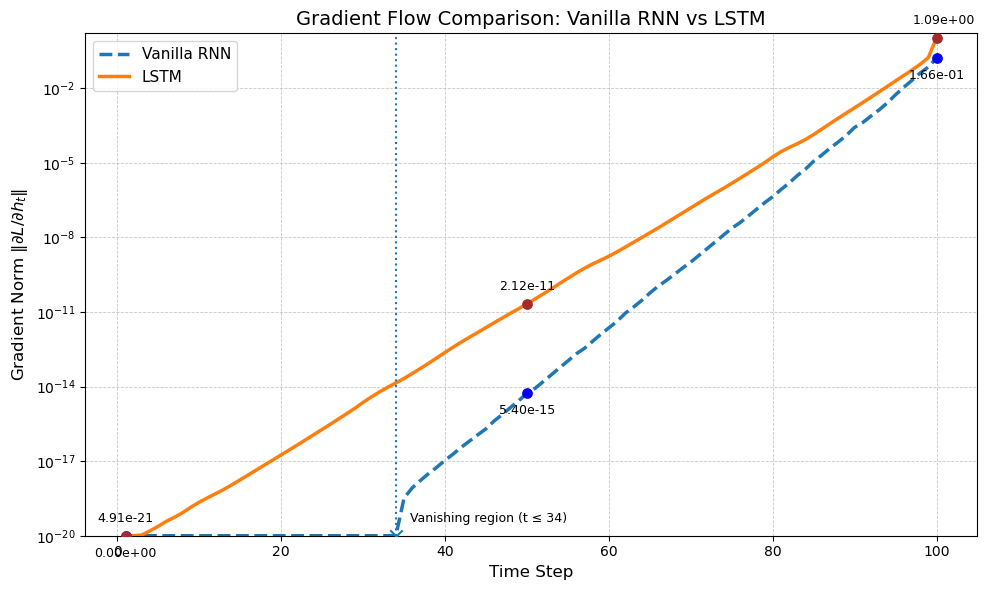

In [35]:
plot_rnn_vs_lstm_improved(
    rnn_path="../Report/gradients_rnn.npy",
    lstm_path="../Report/gradients_lstm.npy",
    save_path="../Report/4_10_bptt_decay_rnn_vs_lstm_2.png"
)

# 4.11 GRU vs. LSTM Efficiency

In [19]:
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.hidden_dim = hidden_size
        self.rnn = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.rnn(x)
        out = out[:, -1, :]
        return self.fc(out)


class GRUModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.hidden_dim = hidden_size
        self.rnn = nn.GRU(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.rnn(x)
        out = out[:, -1, :]
        return self.fc(out)

In [22]:
def count_parameters(model):
    total_params = 0
    for p in model.parameters():
        if p.requires_grad:
            total_params+=p.numel()
    return total_params

In [21]:
def create_dataloaders(X_train, y_train, X_val, y_val, batch_size=64):

    train_dataset = TensorDataset(
        torch.tensor(X_train, dtype=torch.float32),
        torch.tensor(y_train, dtype=torch.float32)
    )

    val_dataset = TensorDataset(
        torch.tensor(X_val, dtype=torch.float32),
        torch.tensor(y_val, dtype=torch.float32)
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=False,
        drop_last=True
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False
    )

    return train_loader, val_loader

In [6]:
def train_and_evaluate_batch(model, 
                             X_train, y_train, 
                             X_val, y_val,
                             epochs=10, lr=1e-3, device="cpu"):

    model = model.to(device)

    # Convert once
    X_train = torch.tensor(X_train, dtype=torch.float32).to(device)
    y_train = torch.tensor(y_train, dtype=torch.float32).to(device)

    X_val = torch.tensor(X_val, dtype=torch.float32).to(device)
    y_val = torch.tensor(y_val, dtype=torch.float32).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    epoch_times = []
    val_losses = []

    for epoch in range(epochs):
        start_time = time.time()

        # ---- Training (Full Batch) ----
        model.train()

        optimizer.zero_grad()

        preds = model(X_train)
        loss = criterion(preds, y_train)

        loss.backward()

        # Gradient clipping (important for RNNs)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()

        # ---- Validation ----
        model.eval()
        with torch.no_grad():
            val_preds = model(X_val)
            val_loss = criterion(val_preds, y_val).item()

        val_losses.append(val_loss)

        epoch_time = time.time() - start_time
        epoch_times.append(epoch_time)

        print(f"Epoch {epoch+1}: Val MSE = {val_loss:.4f}, Time = {epoch_time:.2f}s")

    avg_epoch_time = sum(epoch_times) / len(epoch_times)
    best_val_mse = min(val_losses)

    return best_val_mse, avg_epoch_time

In [30]:
input_columns = ['co', 'no', 'no2', 'o3', 'so2', 'pm2_5', 'pm10', 'nh3']
target_columns = 'pm2_5'

# Getting and Flattening Data
phase4_data = get_phase4_data(input_columns, target_columns, sliding_window = 100, time_steps = 24)
std_scaler_data, std_scaler_target = phase4_data['std_scalers'] # Needed to re-construct the original values

X_train, y_train = phase4_data['train']
X_val, y_val = phase4_data['val']
X_test, y_test = phase4_data['test']

X_train = torch.tensor(X_train, dtype = torch.float32).to(device)
X_val = torch.tensor(X_val, dtype = torch.float32).to(device)
X_test = torch.tensor(X_test, dtype = torch.float32).to(device)

y_train = torch.tensor(y_train, dtype = torch.float32).to(device)
y_val =  torch.tensor(y_val, dtype = torch.float32).to(device)
y_test = torch.tensor(y_test, dtype = torch.float32).to(device)

Standard Scaler applied on Data.

Input Data Shape: (18776, 8)
Input Target Shape: (18776, 1)

########## Dimensions of Original Dataset ##########

Train Data Shape: (13143, 8)
Train Target Shape: (13143, 1)
Validation Data Shape: (2817, 8)
Validation Target Shape: (2817, 1)
Test Data Shape: (2816, 8)
Test Target Shape: (2816, 1)

########## Dimensions After Flattening ##########

Train Data Shape: (13019, 100, 8)
Train Target Shape: (13019, 1)
Validation Data Shape: (2693, 100, 8)
Validation Target Shape: (2693, 1)
Test Data Shape: (2692, 100, 8)
Test Target Shape: (2692, 1)


In [31]:
device = torch.device("mps") 

input_size = 8
hidden_size = 64
output_size = 1

# Initialize models
lstm_model = LSTMModel(input_size, hidden_size, output_size)
gru_model = GRUModel(input_size, hidden_size, output_size)

# ---- Parameter Count ----
lstm_params = count_parameters(lstm_model)
gru_params = count_parameters(gru_model)

print("Parameter Count:")
print(f"LSTM: {lstm_params}")
print(f"GRU : {gru_params}")

Parameter Count:
LSTM: 19009
GRU : 14273


In [34]:
# ---- Train LSTM ----

print("\nTraining LSTM...")
device = torch.device("mps") 
lstm_val_mse, lstm_time = train_and_evaluate_batch(
    lstm_model, X_train, y_train,
    X_val, y_val, device=device,epochs = 25)


Training LSTM...
Epoch 1: Val MSE = 0.3930, Time = 1.91s
Epoch 2: Val MSE = 0.3876, Time = 0.62s
Epoch 3: Val MSE = 0.3827, Time = 0.62s
Epoch 4: Val MSE = 0.3784, Time = 0.62s
Epoch 5: Val MSE = 0.3743, Time = 0.65s
Epoch 6: Val MSE = 0.3704, Time = 0.66s
Epoch 7: Val MSE = 0.3664, Time = 0.62s
Epoch 8: Val MSE = 0.3618, Time = 0.64s
Epoch 9: Val MSE = 0.3563, Time = 0.61s
Epoch 10: Val MSE = 0.3498, Time = 0.61s
Epoch 11: Val MSE = 0.3427, Time = 0.60s
Epoch 12: Val MSE = 0.3353, Time = 0.61s
Epoch 13: Val MSE = 0.3283, Time = 0.64s
Epoch 14: Val MSE = 0.3221, Time = 0.63s
Epoch 15: Val MSE = 0.3170, Time = 0.62s
Epoch 16: Val MSE = 0.3133, Time = 0.61s
Epoch 17: Val MSE = 0.3108, Time = 0.64s
Epoch 18: Val MSE = 0.3095, Time = 0.63s
Epoch 19: Val MSE = 0.3095, Time = 0.62s
Epoch 20: Val MSE = 0.3104, Time = 0.63s
Epoch 21: Val MSE = 0.3120, Time = 0.62s
Epoch 22: Val MSE = 0.3140, Time = 0.61s
Epoch 23: Val MSE = 0.3158, Time = 0.61s
Epoch 24: Val MSE = 0.3167, Time = 0.62s
Epoch 2

In [35]:
# ---- Train GRU ----
print("\nTraining GRU...")
device = torch.device("mps") 
gru_val_mse, gru_time = train_and_evaluate_batch(
    gru_model,X_train, y_train,
    X_val, y_val, device=device, epochs = 25)


Training GRU...
Epoch 1: Val MSE = 0.6080, Time = 0.88s
Epoch 2: Val MSE = 0.5609, Time = 0.44s
Epoch 3: Val MSE = 0.5171, Time = 0.45s
Epoch 4: Val MSE = 0.4768, Time = 0.45s
Epoch 5: Val MSE = 0.4402, Time = 0.44s
Epoch 6: Val MSE = 0.4075, Time = 0.44s
Epoch 7: Val MSE = 0.3790, Time = 0.44s
Epoch 8: Val MSE = 0.3550, Time = 0.44s
Epoch 9: Val MSE = 0.3356, Time = 0.44s
Epoch 10: Val MSE = 0.3209, Time = 0.44s
Epoch 11: Val MSE = 0.3104, Time = 0.45s
Epoch 12: Val MSE = 0.3037, Time = 0.45s
Epoch 13: Val MSE = 0.2998, Time = 0.44s
Epoch 14: Val MSE = 0.2978, Time = 0.44s
Epoch 15: Val MSE = 0.2971, Time = 0.45s
Epoch 16: Val MSE = 0.2972, Time = 0.45s
Epoch 17: Val MSE = 0.2980, Time = 0.44s
Epoch 18: Val MSE = 0.2995, Time = 0.45s
Epoch 19: Val MSE = 0.3016, Time = 0.44s
Epoch 20: Val MSE = 0.3044, Time = 0.45s
Epoch 21: Val MSE = 0.3077, Time = 0.44s
Epoch 22: Val MSE = 0.3113, Time = 0.45s
Epoch 23: Val MSE = 0.3150, Time = 0.46s
Epoch 24: Val MSE = 0.3184, Time = 0.45s
Epoch 25

In [36]:
# ---- Final Comparison ----
print("\n===== FINAL RESULTS =====")
print(f"LSTM -> Val MSE: {lstm_val_mse:.4f}, Time/Epoch: {lstm_time:.2f}s")
print(f"GRU  -> Val MSE: {gru_val_mse:.4f}, Time/Epoch: {gru_time:.2f}s")


===== FINAL RESULTS =====
LSTM -> Val MSE: 0.3095, Time/Epoch: 0.67s
GRU  -> Val MSE: 0.2971, Time/Epoch: 0.46s


# 4.12 Sequence-to-Sequence Forecasting

In [37]:
def flatten_data_seq2seq(X, y, window=72, pred_len=24):

    X_flat, y_flat = [], []
    curr_index = window

    while (curr_index + pred_len) <= X.shape[0]:

        # Input: past 72 steps
        X_flat.append(X[curr_index-window:curr_index])

        # Target: next 24 steps (sequence)
        y_flat.append(y[curr_index:curr_index+pred_len])

        curr_index += 1

    return np.array(X_flat), np.array(y_flat)

In [38]:
def get_phase4_seq2seq_data(input_columns, target_columns, time_steps = 24, sliding_window = 72, preprocess = True):
    # Creating Dataframe
    data_path = "../delhi_aqi.csv" 
    df = pd.read_csv(data_path)
    
    # Input Data
    X = np.array(df[input_columns].copy())
    y = np.array(df[[target_columns]].copy())
    
    # Train-Validation-Split Split (70-15-15)
    train_pct = 0.7
    val_pct = 0.15
    test_pct = 0.15
    
    
    train_index = int(X.shape[0]*train_pct)
    val_index = train_index + int(math.ceil(X.shape[0]*val_pct))
    
    X_train = X[:train_index].copy() # Training Data
    X_val = X[train_index:val_index].copy() # Validation Data
    X_test = X[val_index:].copy() # Test Data

    y_train = y[:train_index].copy() # Training Data
    y_val = y[train_index:val_index].copy() # Validation Data
    y_test = y[val_index:].copy() # Test Data

    std_scaler = StandardScaler()
    std_scaler_target = StandardScaler()

    # Pre-processing Data
    if preprocess:
        print("Standard Scaler applied on Data.")
        # --- Correct scaling ---
        X_train = std_scaler.fit_transform(X_train)
        X_val   = std_scaler.transform(X_val)
        X_test  = std_scaler.transform(X_test)
        
        y_train = std_scaler_target.fit_transform(y_train) 
        y_val   = std_scaler_target.transform(y_val)
        y_test  = std_scaler_target.transform(y_test)

    print()
    print("Input Data Shape:", X.shape)
    print("Input Target Shape:", y.shape)
    
    print()
    print("#"*10, "Dimensions of Original Dataset","#"*10)
    print()
    
    print(f"Train Data Shape: {X_train.shape}")
    print(f"Train Target Shape: {y_train.shape}")
    
    print(f"Validation Data Shape: {X_val.shape}")
    print(f"Validation Target Shape: {y_val.shape}")
    
    print(f"Test Data Shape: {X_test.shape}")
    print(f"Test Target Shape: {y_test.shape}")
    
    print()
    print("#"*10, "Dimensions After Flattening","#"*10)
    print()
    X_train, y_train = flatten_data_seq2seq(X_train,y_train, window = sliding_window)
    X_val, y_val = flatten_data_seq2seq(X_val,y_val, window = sliding_window)
    X_test, y_test = flatten_data_seq2seq(X_test, y_test, window = sliding_window)
    
    print(f"Train Data Shape: {X_train.shape}")
    print(f"Train Target Shape: {y_train.shape}")
    
    print(f"Validation Data Shape: {X_val.shape}")
    print(f"Validation Target Shape: {y_val.shape}")
    
    print(f"Test Data Shape: {X_test.shape}")
    print(f"Test Target Shape: {y_test.shape}")
    
    
    
    return {
        'train': (X_train, y_train),
        'val': (X_val, y_val),
        'test': (X_test, y_test),
        'std_scalers': (std_scaler, std_scaler_target)
    }

In [11]:
class Seq2SeqLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()

        self.hidden_size = hidden_size

        # Encoder
        self.encoder = nn.LSTM(input_size, hidden_size, batch_first=True)

        # Decoder
        self.decoder = nn.LSTM(output_size, hidden_size, batch_first=True)

        # Output projection
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, X, target_seq=None, teacher_forcing_ratio=0.5):
        """
        X: (batch, 72, input_size)
        target_seq: (batch, 24, 1)
        """

        batch_size = X.size(0)
        pred_len = 24

        # ---- Encoder ----
        _, (h, c) = self.encoder(X)

        # ---- Decoder ----
        outputs = []
        decoder_input = torch.zeros(batch_size, 1, 1, device=X.device)  # start token

        for t in range(pred_len):
            out, (h, c) = self.decoder(decoder_input, (h, c))
            pred = self.fc(out)  # (batch, 1, 1)

            outputs.append(pred)

            # Teacher forcing
            if target_seq is not None and torch.rand(1).item() < teacher_forcing_ratio:
                decoder_input = target_seq[:, t:t+1, :]
            else:
                decoder_input = pred

        outputs = torch.cat(outputs, dim=1)  # (batch, 24, 1)
        return outputs

In [39]:
import torch
import torch.nn as nn

class Seq2SeqLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()

        self.hidden_size = hidden_size

        # Encoder
        self.encoder = nn.LSTM(input_size, hidden_size, batch_first=True)

        # Decoder
        self.decoder = nn.LSTM(output_size, hidden_size, batch_first=True)

        # Output projection
        self.fc = nn.Linear(hidden_size, output_size)

        # Dropout (helps avoid trivial smooth outputs)
        self.dropout = nn.Dropout(0.2)

    def forward(self, X, target_seq=None, teacher_forcing_ratio=0.5):
        """
        X: (batch, 72, input_size)
        target_seq: (batch, 24, 1)
        """

        batch_size = X.size(0)
        pred_len = 24

        # ---- Encoder ----
        _, (h, c) = self.encoder(X)

        # ---- Decoder ----
        outputs = []

        # Use last observed target instead of zeros
        # Assuming target is pm2_5 and is one of input features
        decoder_input = X[:, -1:, 0:1]  # (batch, 1, 1)

        for t in range(pred_len):

            out, (h, c) = self.decoder(decoder_input, (h, c))
            out = self.dropout(out)

            # Residual prediction (predict delta)
            pred = self.fc(out) + decoder_input

            outputs.append(pred)

            # Stable teacher forcing
            if target_seq is not None and torch.rand(1).item() < teacher_forcing_ratio:
                decoder_input = target_seq[:, t:t+1, :]
            else:
                decoder_input = pred

        outputs = torch.cat(outputs, dim=1)
        return outputs

In [5]:
def train_seq2seq(model, X_train, y_train, X_val, y_val, epochs=10, lr=1e-3, device="cpu"):

    model.to(device)

    X_train = torch.tensor(X_train, dtype=torch.float32).to(device)
    y_train = torch.tensor(y_train, dtype=torch.float32).to(device)

    X_val = torch.tensor(X_val, dtype=torch.float32).to(device)
    y_val = torch.tensor(y_val, dtype=torch.float32).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    for epoch in range(epochs):
        model.train()

        optimizer.zero_grad()

        preds = model(X_train, y_train, teacher_forcing_ratio=0.5)
        loss = criterion(preds, y_train)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        # Validation
        model.eval()
        with torch.no_grad():
            val_preds = model(X_val, teacher_forcing_ratio=0.0)
            val_loss = criterion(val_preds, y_val)

        print(f"Epoch {epoch+1}: Train Loss={loss.item():.4f}, Val Loss={val_loss.item():.4f}")

In [6]:
def train_seq2seq(model, X_train, y_train, X_val, y_val, 
                 epochs=50, lr=1e-3, device="cpu",
                 patience=5, min_delta=1e-4):

    model.to(device)

    X_train = torch.tensor(X_train, dtype=torch.float32).to(device)
    y_train = torch.tensor(y_train, dtype=torch.float32).to(device)

    X_val = torch.tensor(X_val, dtype=torch.float32).to(device)
    y_val = torch.tensor(y_val, dtype=torch.float32).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    best_val_loss = float('inf')
    patience_counter = 0

    best_model_state = copy.deepcopy(model.state_dict())

    train_losses = []
    val_losses = []

    for epoch in range(epochs):

        # ---- Training ----
        model.train()
        optimizer.zero_grad()

        preds = model(X_train, y_train, teacher_forcing_ratio=0.5)
        loss = criterion(preds, y_train)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        # ---- Validation ----
        model.eval()
        with torch.no_grad():
            val_preds = model(X_val, teacher_forcing_ratio=0.0)
            val_loss = criterion(val_preds, y_val)

        train_losses.append(loss.item())
        val_losses.append(val_loss.item())

        print(f"Epoch {epoch+1}: Train Loss={loss.item():.4f}, Val Loss={val_loss.item():.4f}")

        # ---- Early Stopping Logic ----
        if val_loss.item() < best_val_loss - min_delta:
            best_val_loss = val_loss.item()
            patience_counter = 0

            # Save best model
            best_model_state = copy.deepcopy(model.state_dict())

        else:
            patience_counter += 1

        if patience_counter >= patience:
            print(f"\nEarly stopping triggered at epoch {epoch+1}")
            break

    # ---- Restore Best Model ----
    model.load_state_dict(best_model_state)

    return {
        "model": model,
        "train_losses": train_losses,
        "val_losses": val_losses,
        "best_val_loss": best_val_loss
    }

In [45]:
import copy
import torch
import torch.nn as nn

def train_seq2seq(model, X_train, y_train, X_val, y_val, 
                 epochs=50, lr=5e-4, device="cpu",
                 patience=5, min_delta=1e-4):

    model.to(device)

    X_train = torch.tensor(X_train, dtype=torch.float32).to(device)
    y_train = torch.tensor(y_train, dtype=torch.float32).to(device)

    X_val = torch.tensor(X_val, dtype=torch.float32).to(device)
    y_val = torch.tensor(y_val, dtype=torch.float32).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    criterion = nn.MSELoss()

    best_val_loss = float('inf')
    patience_counter = 0
    best_model_state = copy.deepcopy(model.state_dict())

    train_losses, val_losses = [], []

    for epoch in range(epochs):

        # ---- Scheduled Teacher Forcing ----
        tf_ratio = max(0.1, 0.7 * (0.95 ** epoch))

        # ---- Training ----
        model.train()
        optimizer.zero_grad()

        preds = model(X_train, y_train, teacher_forcing_ratio=tf_ratio)
        loss = criterion(preds, y_train)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        # ---- Validation ----
        model.eval()
        with torch.no_grad():
            val_preds = model(X_val, teacher_forcing_ratio=0.0)
            val_loss = criterion(val_preds, y_val)

        train_losses.append(loss.item())
        val_losses.append(val_loss.item())

        print(f"Epoch {epoch+1}: Train={loss.item():.4f}, Val={val_loss.item():.4f}, TF={tf_ratio:.3f}")

        # ---- Early Stopping ----
        if val_loss.item() < best_val_loss - min_delta:
            best_val_loss = val_loss.item()
            patience_counter = 0
            best_model_state = copy.deepcopy(model.state_dict())
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print(f"\nEarly stopping at epoch {epoch+1}")
            break

    model.load_state_dict(best_model_state)

    return {
        "model": model,
        "train_losses": train_losses,
        "val_losses": val_losses,
        "best_val_loss": best_val_loss
    }

In [41]:
def predict_seq(model, X):
    model.eval()

    with torch.no_grad():
        preds = model(X, teacher_forcing_ratio=0.0)

    return preds

In [55]:
def plot_prediction(model, X_test, y_test, idx=0, scaler=None, device="cpu", save_path=None):

    import matplotlib.pyplot as plt
    import numpy as np

    model.to(device)

    X_sample = torch.tensor(X_test[idx:idx+1], dtype=torch.float32).to(device)
    y_true = y_test[idx]

    preds = predict_seq(model, X_sample).cpu().numpy()[0]

    # Ensure numpy
    if isinstance(y_true, torch.Tensor):
        y_true = y_true.cpu().numpy()

    # Inverse scaling
    if scaler is not None:
        preds = scaler.inverse_transform(preds)
        y_true = scaler.inverse_transform(y_true)

    # Flatten
    y_true = y_true.squeeze()
    preds = preds.squeeze()

    time_steps = np.arange(len(y_true))

    # ---- Plot Styling ----
    plt.figure(figsize=(10, 5))

    plt.plot(time_steps, y_true, 
             linewidth=2.5, marker='o', markersize=4,
             label="Ground Truth")

    plt.plot(time_steps, preds, 
             linewidth=2.5, linestyle='--', marker='s', markersize=4,
             label="Prediction")

    # Axis labels
    plt.xlabel("Time Step (Hours Ahead)", fontsize=12)
    plt.ylabel("PM2.5", fontsize=12)

    # Title
    plt.title("24-step Forecast vs Ground Truth", fontsize=14, pad=10)

    # Grid (light, non-intrusive)
    plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.6)

    # Legend
    plt.legend(frameon=True, fontsize=10)

    # Tight layout for reports
    plt.tight_layout()

    # Save high-quality figure
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')

    plt.show()

In [43]:
input_columns = ['co', 'no', 'no2', 'o3', 'so2', 'pm2_5', 'pm10', 'nh3']
target_columns = 'pm2_5'

# Getting and Flattening Data
phase4_data = get_phase4_seq2seq_data(input_columns, target_columns, sliding_window = 72, time_steps = 24)
std_scaler_data, std_scaler_target = phase4_data['std_scalers'] # Needed to re-construct the original values

X_train, y_train = phase4_data['train']
X_val, y_val = phase4_data['val']
X_test, y_test = phase4_data['test']

X_train = torch.tensor(X_train, dtype = torch.float32).to(device)
X_val = torch.tensor(X_val, dtype = torch.float32).to(device)
X_test = torch.tensor(X_test, dtype = torch.float32).to(device)

y_train = torch.tensor(y_train, dtype = torch.float32).to(device)
y_val =  torch.tensor(y_val, dtype = torch.float32).to(device)
y_test = torch.tensor(y_test, dtype = torch.float32).to(device)

Standard Scaler applied on Data.

Input Data Shape: (18776, 8)
Input Target Shape: (18776, 1)

########## Dimensions of Original Dataset ##########

Train Data Shape: (13143, 8)
Train Target Shape: (13143, 1)
Validation Data Shape: (2817, 8)
Validation Target Shape: (2817, 1)
Test Data Shape: (2816, 8)
Test Target Shape: (2816, 1)

########## Dimensions After Flattening ##########

Train Data Shape: (13048, 72, 8)
Train Target Shape: (13048, 24, 1)
Validation Data Shape: (2722, 72, 8)
Validation Target Shape: (2722, 24, 1)
Test Data Shape: (2721, 72, 8)
Test Target Shape: (2721, 24, 1)


In [54]:
input_size = 8
hidden_size = 256
output_size = 1

lr = 5e-4
epochs = 200
patience = 10
min_delta = 1e-4
weight_decay = 1e-5

model = Seq2SeqLSTM(input_size, hidden_size, output_size)

results = train_seq2seq(model, X_train, y_train, X_val, y_val, device="cpu",
                        patience = 20, epochs = 200, lr = 5e-4, min_delta = 1e-4)

Epoch 1: Train=0.1270, Val=0.4006, TF=0.700
Epoch 2: Train=0.2521, Val=0.3574, TF=0.665
Epoch 3: Train=0.1795, Val=0.3401, TF=0.632
Epoch 4: Train=0.2512, Val=0.3578, TF=0.600
Epoch 5: Train=0.1506, Val=0.3871, TF=0.570
Epoch 6: Train=0.2089, Val=0.4187, TF=0.542
Epoch 7: Train=0.1780, Val=0.4413, TF=0.515
Epoch 8: Train=0.1763, Val=0.4507, TF=0.489
Epoch 9: Train=0.2218, Val=0.4469, TF=0.464
Epoch 10: Train=0.2763, Val=0.4373, TF=0.441
Epoch 11: Train=0.1461, Val=0.4288, TF=0.419
Epoch 12: Train=0.2658, Val=0.4233, TF=0.398
Epoch 13: Train=0.1958, Val=0.4208, TF=0.378
Epoch 14: Train=0.3215, Val=0.4076, TF=0.359
Epoch 15: Train=0.1990, Val=0.3968, TF=0.341
Epoch 16: Train=0.3774, Val=0.3796, TF=0.324
Epoch 17: Train=0.2340, Val=0.3659, TF=0.308
Epoch 18: Train=0.3739, Val=0.3548, TF=0.293
Epoch 19: Train=0.3729, Val=0.3447, TF=0.278
Epoch 20: Train=0.4284, Val=0.3288, TF=0.264
Epoch 21: Train=0.2145, Val=0.3165, TF=0.251
Epoch 22: Train=0.3234, Val=0.3097, TF=0.238
Epoch 23: Train=0.3

In [57]:
save_dir = "../Models"
model_num = 3
save_path = os.path.join(save_dir, f"4_12_{model_num}.pth")
model = results["model"]
torch.save(model.state_dict(),save_path)

In [59]:
save_dir = "../Models"
model_num = 3
save_path = os.path.join(save_dir, f"4_12_{model_num}.pth")

model = Seq2SeqLSTM(8, 256, 1)
model.load_state_dict(torch.load(save_path, map_location="cpu"))
model.eval()

Seq2SeqLSTM(
  (encoder): LSTM(8, 256, batch_first=True)
  (decoder): LSTM(1, 256, batch_first=True)
  (fc): Linear(in_features=256, out_features=1, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
)

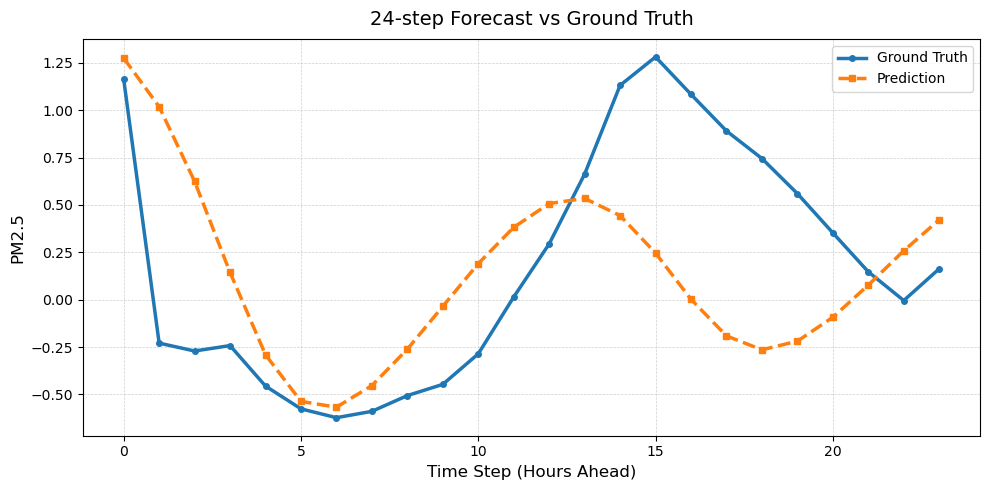

In [60]:
img_save_path = "../Report/4_12_predictions"
plot_prediction(model, X_test, y_test, idx=2,save_path = img_save_path)